# 06 Reinforcement learning: can an agent out-think the pit wall's rules?

Phase 4d. Strategy as a sequential decision problem: **one episode = one race, one step = one lap**.
Before each lap is finished the agent sees the race state and chooses

| action | meaning |
|---|---|
| 0 | stay out |
| 1 / 2 / 3 | pit, fit new SOFT / MEDIUM / HARD |

It's trained with **PPO** on random races of the reference race, then compared with the best
**fixed** strategy (notebook 04) and the best **reactive** rule (notebook 05) **on the same 4,000
races**. The lap model is identical in all three (tests check it to 1e-12 s), so differences are
purely about decisions.

In [1]:
# Run from the repo root so `import src...` works.
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stable_baselines3 import PPO

from src.models.advanced.rl_agent import (MODELS_DIR, RaceTimeEvalCallback, agent_policy,
                                          pit_decisions, train_ppo)
from src.models.advanced.strategy_env import (PitStopEnv, RaceState, fixed_strategy_policy,
                                              reactive_policy, rollout)
from src.models.baselines import monte_carlo as mc
from src.models.baselines.race_model import reference_race
from src.models.baselines.reactive import ReactivePolicy

pd.set_option("display.max_columns", 40, "display.width", 200)
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 2,
    "legend.frameon": False,
})
FIXED, REACTIVE, AGENT, MUTED, INK = "#8a8984", "#eb6834", "#2a78d6", "#8a8984", "#0b0b0b"
COMPOUND_COLORS = {"SOFT": "#e34948", "MEDIUM": "#eda100", "HARD": "#8a8984"}

params = reference_race()
L = params.total_laps
# The same 4,000 races as notebook 05 (same seed, same draw order).
rng = np.random.default_rng(0)
N = 4000
sc_mask = mc.draw_safety_car(rng, N, L, params.sc_hazard_per_lap, params.sc_duration_laps)
noise = mc.draw_lap_noise(rng, N, params)

## 1 What the agent sees

The observation is 9 numbers, all scaled to [0, 1] (neural networks learn badly from
inputs on very different scales, e.g. lap 57 next to a 0/1 flag).

**What to look for**
* The SC flag switches on for a few laps; tyre age resets to 1/57 after a stop.
* The agent never sees the future: not when the next SC comes, not the noise of upcoming laps.

In [2]:
obs_names = ["lap/L", "laps_left/L", "tyre_age/L", "is_SOFT", "is_MEDIUM", "is_HARD", "SC_out", "stops/3", "two_compounds"]
race = int(np.flatnonzero(sc_mask[:, 15:22].any(axis=1))[0])  # a race with an SC around laps 16-22
state = RaceState(params, sc_mask[race:race + 1], noise[race:race + 1])
rows = []
while not state.done:
    action = 3 if state.lap == 24 else 0  # demo: pit for HARD on lap 24
    rows.append({"lap": state.lap, **dict(zip(obs_names, state.observe()[0].round(3))),
                 "action": action, "seconds": float(state.step(action)[0])})
pd.DataFrame(rows).iloc[12:28]

,lap,lap/L,laps_left/L,tyre_age/L,is_SOFT,is_MEDIUM,is_HARD,SC_out,stops/3,two_compounds,action,seconds
12,13,0.228,0.772,0.228,0.0,1.0,0.0,0.0,0.000,0.0,0,99.592347
13,14,0.246,0.754,0.246,0.0,1.0,0.0,0.0,0.000,0.0,0,99.846215
14,15,0.263,0.737,0.263,0.0,1.0,0.0,0.0,0.000,0.0,0,100.176739
15,16,0.281,0.719,0.281,0.0,1.0,0.0,0.0,0.000,0.0,0,99.562206
16,17,0.298,0.702,0.298,0.0,1.0,0.0,0.0,0.000,0.0,0,99.415898
17,18,0.316,0.684,0.316,0.0,1.0,0.0,1.0,0.000,0.0,0,134.400000
18,19,0.333,0.667,0.333,0.0,1.0,0.0,1.0,0.000,0.0,0,134.400000
19,20,0.351,0.649,0.351,0.0,1.0,0.0,1.0,0.000,0.0,0,134.400000
20,21,0.368,0.632,0.368,0.0,1.0,0.0,1.0,0.000,0.0,0,134.400000
21,22,0.386,0.614,0.386,0.0,1.0,0.0,0.0,0.000,0.0,0,99.141424


## 2 Training (or loading) the agent

PPO plays random races in 8 parallel environments. Every 16,384 laps (~290 races) it updates its
policy network towards decisions that turned out better than expected. A callback replays the
**greedy** policy on 1,000 fixed evaluation races every 250,000 laps, to show progress in race-time units.

**Hyperparameters matter a lot here.** The first attempt (constant learning rate 3e-4, ~8k-lap
batches) found a decent one-stop after 450k laps, then drifted away to two-stoppers ending ~10 s
worse than the fixed strategy. A 4-way comparison, 3M laps each, on the evaluation races:

| config | change | final vs best fixed |
|---|---|---|
| first attempt (1M laps) | lr 3e-4, batch 512, 8k-lap updates | **+9.98 s** (worse) |
| A | lr 1e-4, bigger batches | −0.35 s |
| B | γ = 0.995 | +0.01 s |
| C | lr decaying to 0, no entropy bonus | −0.33 s |
| **D** | **lr decaying to 0, entropy 0.001, 128×128 net** | **−0.40 s** |

The race outcome is very noisy compared with the effect of one decision (one SC can swing a race by
~40 s, a well-timed stop is worth ~1 s), so the policy needs large batches to average the noise out
and a learning rate that shrinks so it can settle. D is now `DEFAULT_PPO_PARAMS`; here it trains for
6M laps (~10 min on a laptop CPU). The model is saved to `data/models/` and reloaded on later runs;
set `RETRAIN = True` to train again.

In [3]:
RETRAIN = False
TRAIN_STEPS = 6_000_000
model_path = MODELS_DIR / "ppo_pitstop.zip"
curve_path = MODELS_DIR / "ppo_pitstop_curve.json"

# Fixed evaluation races for the learning curve (separate from the 4,000 test races).
eval_rng = np.random.default_rng(123)
eval_sc = mc.draw_safety_car(eval_rng, 1000, L, params.sc_hazard_per_lap, params.sc_duration_laps)
eval_noise = mc.draw_lap_noise(eval_rng, 1000, params)

if RETRAIN or not model_path.exists():
    callback = RaceTimeEvalCallback(params, eval_sc, eval_noise, eval_freq=250_000)
    t0 = time.perf_counter()
    model = train_ppo(params, total_timesteps=TRAIN_STEPS, callback=callback, seed=0)
    print(f"trained {TRAIN_STEPS:,} laps in {time.perf_counter() - t0:.0f} s")
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    model.save(model_path)
    curve_path.write_text(json.dumps({"timesteps": callback.timesteps, "mean_race_time_s": callback.mean_race_time_s}))
else:
    model = PPO.load(model_path, device="cpu")
    print(f"loaded {model_path}")
curve = json.loads(curve_path.read_text())

loaded /Users/konwas/Documents/programming/_pitwall-ml/pitwall-ml/data/models/ppo_pitstop.zip


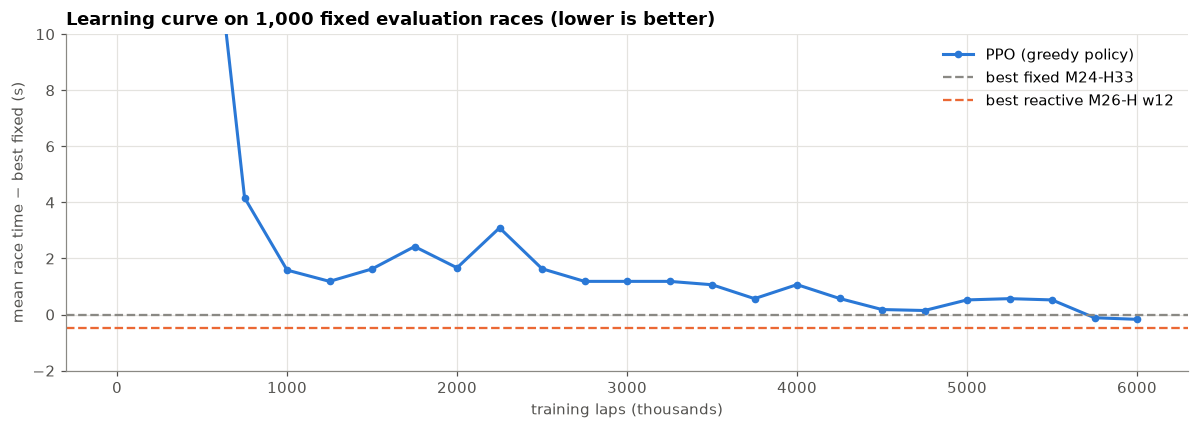

In [4]:
best_fixed = mc.Strategy((("MEDIUM", 24), ("HARD", 33)))
best_reactive = ReactivePolicy("MEDIUM", "HARD", 26, sc_window=12)
eval_fixed = rollout(fixed_strategy_policy(best_fixed, params), params, eval_sc, eval_noise).mean()
eval_reactive = rollout(reactive_policy(best_reactive, params), params, eval_sc, eval_noise).mean()

fig, ax = plt.subplots()
ts, m = np.array(curve["timesteps"]), np.array(curve["mean_race_time_s"])
ax.plot(ts / 1e3, m - eval_fixed, marker="o", markersize=4, color=AGENT, label="PPO (greedy policy)")
ax.axhline(0, color=FIXED, linestyle="--", linewidth=1.5, label=f"best fixed {best_fixed.name}")
ax.axhline(eval_reactive - eval_fixed, color=REACTIVE, linestyle="--", linewidth=1.5, label=f"best reactive {best_reactive.name}")
ax.set_ylim(min(-2, (m - eval_fixed).min() - 0.5), max(10, np.percentile(m - eval_fixed, 20)))
ax.set_xlabel("training laps (thousands)"); ax.set_ylabel("mean race time − best fixed (s)")
ax.set_title("Learning curve on 1,000 fixed evaluation races (lower is better)", loc="left"); ax.legend()
plt.tight_layout()

## 3 Head to head on the 4,000 test races

**What to look for**
* Is the agent's mean race time below the best fixed strategy? Below the best reactive rule?
* `win vs fixed`: share of races where the agent finished ahead of the fixed strategy.

In [5]:
times = {
    f"fixed {best_fixed.name}": rollout(fixed_strategy_policy(best_fixed, params), params, sc_mask, noise),
    f"reactive {best_reactive.name}": rollout(reactive_policy(best_reactive, params), params, sc_mask, noise),
    "PPO agent": rollout(agent_policy(model), params, sc_mask, noise),
}
base = times[f"fixed {best_fixed.name}"]
had_sc = sc_mask.any(axis=1)
summary = pd.DataFrame([
    {"policy": name, "mean_s": t.mean(), "vs_fixed_s": t.mean() - base.mean(),
     "vs_fixed_no_SC_s": (t - base)[~had_sc].mean(), "vs_fixed_with_SC_s": (t - base)[had_sc].mean(),
     "win_vs_fixed": (t < base - 1e-9).mean(), "lose_vs_fixed": (t > base + 1e-9).mean()}
    for name, t in times.items()
])
summary.round(3)

,policy,mean_s,vs_fixed_s,vs_fixed_no_SC_s,vs_fixed_with_SC_s,win_vs_fixed,lose_vs_fixed
0,fixed M24-H33,5732.627,0.000,0.0,0.00,0.000,0.000
1,reactive M26-H w12,5732.103,-0.524,0.1,-1.05,0.142,0.844
2,PPO agent,5732.287,-0.339,0.1,-0.71,0.146,0.841


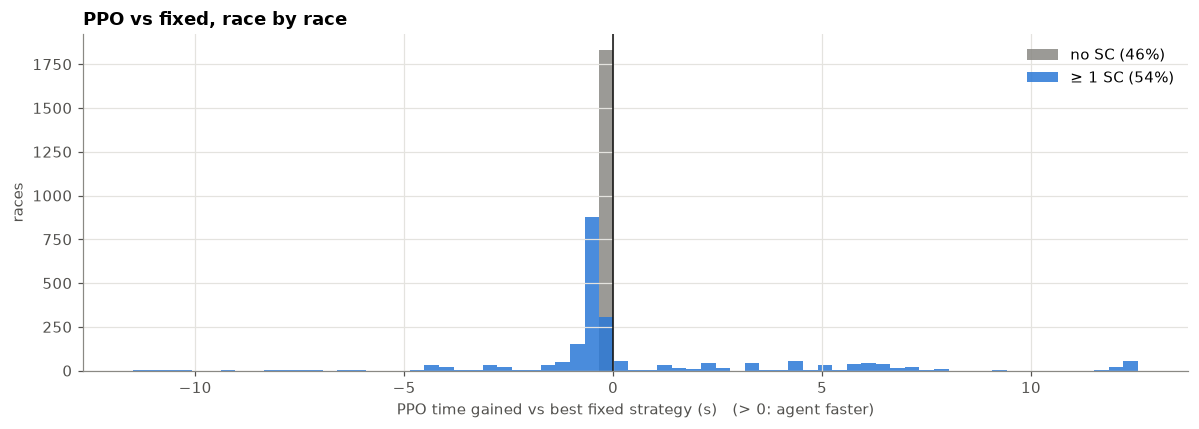

In [6]:
gain = base - times["PPO agent"]
fig, ax = plt.subplots()
lo, hi = np.percentile(gain, [0.5, 99.5])
bins = np.linspace(lo, hi, 70)
ax.hist(gain[~had_sc], bins=bins, color=MUTED, alpha=0.85, label=f"no SC ({(~had_sc).mean():.0%})")
ax.hist(gain[had_sc], bins=bins, color=AGENT, alpha=0.85, label=f"≥ 1 SC ({had_sc.mean():.0%})")
ax.axvline(0, color=INK, linewidth=1)
ax.set_xlabel("PPO time gained vs best fixed strategy (s)   (> 0: agent faster)"); ax.set_ylabel("races")
ax.set_title("PPO vs fixed, race by race", loc="left"); ax.legend()
plt.tight_layout()

## 4 What did the agent learn?

Replay the greedy policy and log every pit stop.

**What to look for**
* How many stops per race, and onto which compounds (does it obey the two-compound rule?).
* **When** it pits without a Safety Car (its "plan"), and whether an SC makes it pit **earlier**,
  the behaviour the reactive rule was hand-written to do.

stops per race: {1: 4000}
new compounds fitted: {'HARD': 4000}
stops made under SC: 23%


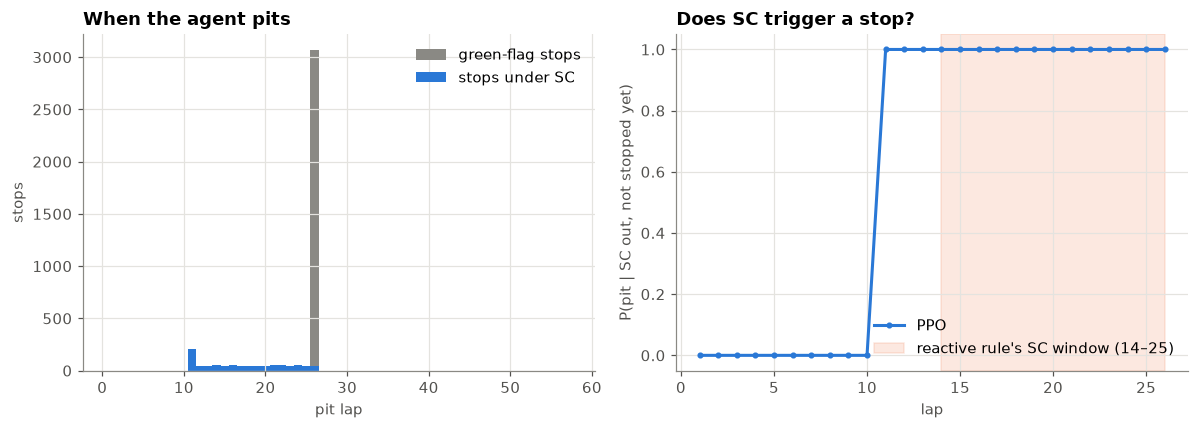

In [8]:
d = pd.DataFrame(pit_decisions(agent_policy(model), params, sc_mask, noise),
                 columns=["race", "lap", "compound", "sc"])
d["compound"] = d["compound"].map(dict(enumerate(params.compounds)))
stops = d.groupby("race").size().reindex(range(N), fill_value=0)
print("stops per race:", stops.value_counts().sort_index().to_dict())
print("new compounds fitted:", d["compound"].value_counts().to_dict())
print(f"stops made under SC: {d['sc'].mean():.0%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.arange(0.5, L + 1.5)
axes[0].hist(d.loc[d.sc == 0, "lap"], bins=bins, color=MUTED, label="green-flag stops")
axes[0].hist(d.loc[d.sc == 1, "lap"], bins=bins, color=AGENT, label="stops under SC")
axes[0].set_xlabel("pit lap"); axes[0].set_ylabel("stops"); axes[0].legend()
axes[0].set_title("When the agent pits", loc="left")

# Probability of pitting on lap l given the SC is out on lap l and the car hasn't stopped yet.
state = RaceState(params, sc_mask, noise)
seen, pitted = np.zeros(L + 1), np.zeros(L + 1)
policy = agent_policy(model)
while not state.done:
    a = np.asarray(policy(state)); eligible = state.sc_now & (state.stops == 0)
    seen[state.lap] += eligible.sum(); pitted[state.lap] += (eligible & (a > 0)).sum()
    state.step(a)
laps = np.arange(L + 1)
ok = seen >= 20
axes[1].plot(laps[ok], pitted[ok] / seen[ok], marker="o", markersize=3, color=AGENT, label="PPO")
w0, w1 = best_reactive.plan_lap - best_reactive.sc_window, best_reactive.plan_lap
axes[1].axvspan(w0, w1, color=REACTIVE, alpha=0.15, label=f"reactive rule's SC window ({w0}–{w1 - 1})")
axes[1].set_ylim(-0.05, 1.05); axes[1].set_xlabel("lap"); axes[1].set_ylabel("P(pit | SC out, not stopped yet)")
axes[1].set_title("Does SC trigger a stop?", loc="left"); axes[1].legend()
plt.tight_layout()

## 5 Takeaways

* **The comparison is fair by construction:** the same 4,000 races, the same lap model,
  only the decisions differ.
* **PPO beats the best fixed strategy** (−0.34 s per race on average, all of it from Safety Car
  races) **but not the best hand-written rule** (−0.52 s).
* **It rediscovered the rule by itself.** Nobody told it about plan laps or SC windows, yet its
  greedy policy is: one stop MEDIUM->HARD, planned on **lap 26** (the same lap as the best rule), and
  pit immediately if a Safety Car appears **from lap 11 on**, a 15-lap window where the rule uses 12.
  Stopping under an SC as early as lap 11 leaves 46 laps on one set of HARDs, which is the most
  likely source of the remaining gap.
* **Why it's hard to learn:** a well-timed SC stop is worth ~1 s on average, while a single SC
  swings a race by ~40 s. The learning curve shows the result: noisy progress, and a hyperparameter
  search was needed before it beat even the fixed strategy.
* **When RL would pay off:** in this race model, the optimal policy is simple enough that a
  2-parameter rule captures it. RL earns its keep when the state is richer (gaps to other cars,
  traffic, tyre temperatures, an opponent's strategy) and no one can write the rule by hand.